# Scania APS - the fault classifier, and what each decision is worth

One binary classifier over 170 anonymised counters, deciding whether a truck's
service issue belongs to the air pressure system. The metric is the dataset's
own and asymmetric on purpose: `cost = 10 * false positives + 500 * false
negatives`.

Fifty to one is why this module, the Truck Fleet department's classification
module, exists beside CMAPSS, whose card names that gap
as limitation 5 and does not address it. Nothing here is imported from
`scania_aps.py`, and this notebook is also the producer: it writes the artifacts
`events/make_events_scania.py` turns into Arkon risk events.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure, get_mlflow_uri

print('arkon_utils loaded')

arkon_utils loaded


The libraries, including XGBoost, MLflow and the SMOTE implementation section 10 needs.

In [2]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import xgboost
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'ml'
PROC_DIR = Path('../../data/02_scania/processed')
CKPT_DIR = Path('../../models/checkpoints/scania')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'xgboost {xgboost.__version__}')
print(f'mlflow  {mlflow.__version__}')

python  3.12.10
pandas  2.3.3
xgboost 3.2.0
mlflow  3.13.0


## 2. The experiment, written out

Two binary choices - keep the missing values or fill them with the training
median, and weight the positive class or not - make four candidates. Each gets
its threshold tuned on out-of-fold probabilities, and **the whole selection runs
on three fold seeds** because one is not enough to resolve a near-tie: an earlier
design used a single split and reported two confident conclusions that three
seeds turned into three different winners.

In [3]:
SEED = 42
FOLDS = 5
# Three fold seeds. One is not enough: it picks a different winner each time.
SELECTION_SEEDS = (42, 7, 2026)

# The challenge metric, from data/02_scania/raw/aps_failure_description.txt.
COST_FALSE_POSITIVE = 10   # an unnecessary check by a mechanic
COST_FALSE_NEGATIVE = 500  # a missed faulty truck, which may break down

# The threshold grid the earlier version of this notebook searched.
GRID = np.arange(0.10, 0.90, 0.01)

XGB_PARAMS = {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05,
              'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': SEED,
              'n_jobs': -1, 'tree_method': 'hist', 'eval_metric': 'aucpr'}

# name, median imputation, class weighting
CANDIDATES = [('nan_weighted', False, True),
              ('nan_plain', False, False),
              ('imputed_weighted', True, True),
              ('imputed_plain', True, False)]

print(f'{len(CANDIDATES)} candidates x {len(SELECTION_SEEDS)} fold seeds x '
      f'{FOLDS} folds = {len(CANDIDATES) * len(SELECTION_SEEDS) * FOLDS} fits '
      f'in the selection alone')

4 candidates x 3 fold seeds x 5 folds = 60 fits in the selection alone


## 3. The reference, read before anything is trained

Whatever the last run recorded. This notebook overwrites that file in section 13,
so it is loaded now while it still describes the previous run, and compared
against in section 14. A difference there would mean the numbers in the model
card and the charter cannot be reproduced from this repository.

In [4]:
META_PATH = CKPT_DIR / 'scania_aps_meta.json'
reference = json.loads(META_PATH.read_text(encoding='utf-8')) if META_PATH.exists() else None

if reference:
    shipped = reference['results'][reference['chosen']]
    print('reference metrics found, recorded by the previous run')
    print(f"  chosen candidate {reference['chosen']} at threshold "
          f"{reference['chosen_threshold']:.6f}")
    print(f"  test cost {shipped['cost']:,}, {shipped['false_positives']} false "
          f"positives, {shipped['false_negatives']} missed, recall {shipped['recall']}")
    print(f"  winner per fold seed: {reference['winner_per_seed']}")
else:
    print('no reference yet: this is the first run')

reference metrics found, recorded by the previous run
  chosen candidate nan_plain at threshold 0.002366
  test cost 10,660, 416 false positives, 13 missed, recall 0.9653
  winner per fold seed: {'42': 'imputed_plain', '7': 'nan_plain', '2026': 'imputed_weighted'}


## 4. Load what notebook 02 prepared

The raw counters with their missing values intact, the imputer and scaler fitted
on the training rows, and the SMOTE-balanced matrix section 10 needs. The imputed
frames are rebuilt here by applying the saved imputer rather than carried as two
more copies of the data.

In [5]:
t0 = time.time()
train = pd.read_parquet(PROC_DIR / 'train_scania_prepared.parquet')
test = pd.read_parquet(PROC_DIR / 'test_scania_prepared.parquet')
textbook_train = pd.read_parquet(PROC_DIR / 'train_scania_textbook.parquet')
imputer = joblib.load(PROC_DIR / 'imputer_scania.pkl')
minmax = joblib.load(PROC_DIR / 'minmax_scania.pkl')

features = [c for c in train.columns if c != 'label']
X_train, y_train = train[features], train.label.to_numpy()
X_test, y_test = test[features], test.label.to_numpy()

imputed_train = pd.DataFrame(imputer.transform(X_train), columns=features)
imputed_test = pd.DataFrame(imputer.transform(X_test), columns=features)

print(f'loaded in {time.time() - t0:.1f}s')
print(f'train {X_train.shape}, {y_train.sum()} failures '
      f'({100 * y_train.mean():.2f}%)')
print(f'test  {X_test.shape}, {y_test.sum()} failures '
      f'({100 * y_test.mean():.2f}%)')
print(f'textbook training matrix {textbook_train[features].shape}, '
      f'{int(textbook_train.label.sum()):,} failures after SMOTE')
print(f'missing cells: raw {100 * X_train.isna().to_numpy().mean():.1f}%, '
      f'imputed {int(imputed_train.isna().to_numpy().sum())}')

loaded in 0.4s
train (60000, 170), 1000 failures (1.67%)
test  (16000, 170), 375 failures (2.34%)
textbook training matrix (118000, 170), 59,000 failures after SMOTE
missing cells: raw 8.3%, imputed 0


## 5. The metric, and an exact threshold search

The search is exact rather than a grid. Sorting the scores once turns every
distinct score into a candidate boundary and the cost at each into a running
count, so the true minimum is found in one pass. That matters here because the
scores cluster hard at zero and a fixed grid steps over the region where the
answer lives.

In [6]:
def counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {'cost': int(COST_FALSE_POSITIVE * fp + COST_FALSE_NEGATIVE * fn),
            'false_positives': int(fp), 'false_negatives': int(fn),
            'true_positives': int(tp), 'true_negatives': int(tn)}


def best_threshold(y_true, scores):
    """The probability cut that minimises cost on these scores, searched exactly."""
    order = np.argsort(-scores)
    labels = y_true[order]
    positives = int(labels.sum())
    true_positives = np.concatenate([[0], np.cumsum(labels)])
    predicted = np.arange(len(labels) + 1)
    false_positives = predicted - true_positives
    false_negatives = positives - true_positives
    costs = (COST_FALSE_POSITIVE * false_positives
             + COST_FALSE_NEGATIVE * false_negatives)
    k = int(np.argmin(costs))
    sorted_scores = scores[order]
    if k == 0:
        cut = float(sorted_scores[0]) + 1e-9
    elif k >= len(sorted_scores):
        cut = float(sorted_scores[-1])
    else:
        cut = float((sorted_scores[k - 1] + sorted_scores[k]) / 2)
    return cut, int(costs[k])


def evaluate(y_true, scores, threshold):
    """Cost first, then the counts that produce it. Cost alone hides the trade."""
    result = counts(y_true, (scores >= threshold).astype(int))
    result['threshold'] = round(float(threshold), 6)
    result['roc_auc'] = round(float(roc_auc_score(y_true, scores)), 4)
    result['pr_auc'] = round(float(average_precision_score(y_true, scores)), 4)
    hits = result['true_positives'] + result['false_positives']
    result['precision'] = round(result['true_positives'] / hits, 4) if hits else 0.0
    result['recall'] = round(
        result['true_positives'] / (result['true_positives'] + result['false_negatives']), 4)
    return result


def grid_threshold(y_true, scores):
    """The best cut the 0.10 to 0.89 grid can reach on these scores."""
    grid_costs = np.array([counts(y_true, (scores >= t).astype(int))['cost'] for t in GRID])
    best = int(np.argmin(grid_costs))
    return float(GRID[best]), int(grid_costs[best])


def make_model(weighted, y):
    params = dict(XGB_PARAMS)
    if weighted:
        params['scale_pos_weight'] = float((y == 0).sum() / max((y == 1).sum(), 1))
    return XGBClassifier(**params)


print('cost metric and threshold search defined')
print(f'a model that flags nothing costs {COST_FALSE_NEGATIVE * int(y_test.sum()):,} '
      f'on the test set')

cost metric and threshold search defined
a model that flags nothing costs 187,500 on the test set


## 6. The selection

Five-fold stratified cross-validation gives one probability per training row from
a model that never saw that row. Sixty fits, and the slow part of this notebook.

**Out-of-fold cost is a ranking device, not a number to compare with the test
figure.** It is computed over 60,000 rows from models each trained on four
fifths; the test cost is over 16,000. The two are never compared here.

In [7]:
def out_of_fold_scores(X, y, weighted, fold_seed):
    """One probability per training row, from a model that never saw that row."""
    scores = np.zeros(len(y), dtype=float)
    splitter = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=fold_seed)
    for fit_index, score_index in splitter.split(X, y):
        model = make_model(weighted, y[fit_index])
        model.fit(X.iloc[fit_index], y[fit_index])
        scores[score_index] = model.predict_proba(X.iloc[score_index])[:, 1]
    return scores


t_selection = time.time()
selection = {}
for name, impute, weighted in CANDIDATES:
    data = imputed_train if impute else X_train
    per_seed = []
    for fold_seed in SELECTION_SEEDS:
        t0 = time.time()
        scores = out_of_fold_scores(data, y_train, weighted, fold_seed)
        threshold, oof_cost = best_threshold(y_train, scores)
        per_seed.append({'fold_seed': fold_seed, 'threshold': round(threshold, 6),
                         'out_of_fold_cost': oof_cost})
        print(f'  {name:<18} seed {fold_seed:<5} cost {oof_cost:>7,}   '
              f'threshold {threshold:.6f}   {time.time() - t0:5.1f}s')
    selection[name] = {
        'median_imputation': impute, 'class_weighting': weighted,
        'per_seed': per_seed,
        'mean_out_of_fold_cost': round(
            sum(s['out_of_fold_cost'] for s in per_seed) / len(per_seed), 1),
        'threshold': round(sum(s['threshold'] for s in per_seed) / len(per_seed), 6)}

print(f'\nselection done in {(time.time() - t_selection) / 60:.1f} minutes')

  nan_weighted       seed 42    cost  35,940   threshold 0.003567   101.1s


  nan_weighted       seed 7     cost  37,990   threshold 0.005470    94.3s


  nan_weighted       seed 2026  cost  36,560   threshold 0.007271    95.7s


  nan_plain          seed 42    cost  35,900   threshold 0.001952    79.8s


  nan_plain          seed 7     cost  35,010   threshold 0.002684    81.2s


...

  imputed_weighted   seed 7     cost  36,860   threshold 0.005877    86.6s


  imputed_weighted   seed 2026  cost  35,010   threshold 0.005142    93.3s


  imputed_plain      seed 42    cost  35,670   threshold 0.003369   101.8s


  imputed_plain      seed 7     cost  35,240   threshold 0.005860    67.3s


  imputed_plain      seed 2026  cost  36,700   threshold 0.004975    66.9s

selection done in 17.8 minutes


## 7. What the selection says

The spread between the best and the worst candidate, and which candidate each seed would have crowned on its own.

In [8]:
means = [v['mean_out_of_fold_cost'] for v in selection.values()]
spread = max(means) / min(means) - 1
winner_per_seed = {}
for i, fold_seed in enumerate(SELECTION_SEEDS):
    winner_per_seed[fold_seed] = min(
        selection, key=lambda k: selection[k]['per_seed'][i]['out_of_fold_cost'])

table = pd.DataFrame([
    {'candidate': name,
     'imputed': v['median_imputation'], 'weighted': v['class_weighting'],
     'mean_oof_cost': v['mean_out_of_fold_cost'],
     **{f'seed_{s["fold_seed"]}': s['out_of_fold_cost'] for s in v['per_seed']},
     'threshold': v['threshold']}
    for name, v in sorted(selection.items(), key=lambda kv: kv[1]['mean_out_of_fold_cost'])])
print(table.to_string(index=False))

chosen = min(selection, key=lambda k: selection[k]['mean_out_of_fold_cost'])
impute = selection[chosen]['median_imputation']
weighted = selection[chosen]['class_weighting']
threshold = selection[chosen]['threshold']

print(f'\nspread between best and worst candidate: {100 * spread:.1f}%')
print(f'winner per seed: {winner_per_seed}')
print(f'chosen on the lowest mean: {chosen}, threshold {threshold:.6f}')

       candidate  imputed  weighted  mean_oof_cost  seed_42  seed_7  seed_2026  threshold
       nan_plain    False     False        35403.3    35900   35010      35300   0.002366
   imputed_plain     True     False        35870.0    35670   35240      36700   0.004735
imputed_weighted     True      True        36410.0    37360   36860      35010   0.005134
    nan_weighted    False      True        36830.0    35940   37990      36560   0.005436

spread between best and worst candidate: 4.0%
winner per seed: {42: 'imputed_plain', 7: 'nan_plain', 2026: 'imputed_weighted'}
chosen on the lowest mean: nan_plain, threshold 0.002366


The same thing drawn, one line per fold seed, with each seed's own winner marked.

  ✓ Saved → assets\ml\scania_model_selection.png


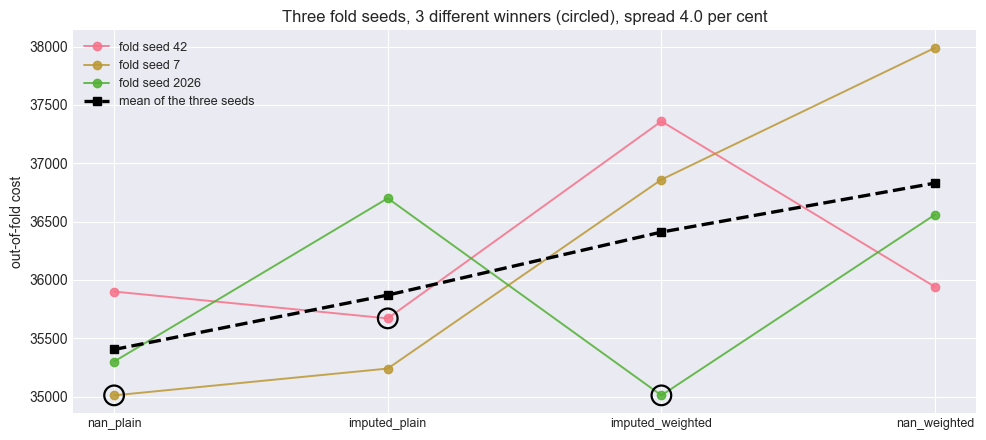

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = list(table.candidate)
x = np.arange(len(order))
for i, fold_seed in enumerate(SELECTION_SEEDS):
    costs = [selection[c]['per_seed'][i]['out_of_fold_cost'] for c in order]
    ax.plot(x, costs, marker='o', linewidth=1.4, alpha=0.85, label=f'fold seed {fold_seed}')
    best = int(np.argmin(costs))
    ax.scatter([x[best]], [costs[best]], s=200, facecolors='none',
               edgecolors='black', linewidths=1.6, zorder=5)
ax.plot(x, [selection[c]['mean_out_of_fold_cost'] for c in order], marker='s',
        linestyle='--', linewidth=2.4, color='black', label='mean of the three seeds')
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=9)
ax.set_ylabel('out-of-fold cost')
ax.set_title(f'Three fold seeds, {len(set(winner_per_seed.values()))} different winners '
             f'(circled), spread {100 * spread:.1f} per cent')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, 'scania_model_selection', subfolder=ASSETS)
plt.show()

## 8. Refit the winner, and score the test set once

The chosen candidate is refitted on every training row, with the mean of its three
thresholds, and applied to the test set a single time. Everything after this point
is reporting, not choosing.

In [10]:
fit_data = imputed_train if impute else X_train
score_data = imputed_test if impute else X_test

t0 = time.time()
model = make_model(weighted, y_train).fit(fit_data, y_train)
test_scores = model.predict_proba(score_data)[:, 1]
primary = evaluate(y_test, test_scores, threshold)

print(f'refit in {time.time() - t0:.1f}s')
print(f'TEST cost {primary["cost"]:,}   FP {primary["false_positives"]}   '
      f'FN {primary["false_negatives"]}   TP {primary["true_positives"]}')
print(f'recall {primary["recall"]}   precision {primary["precision"]}   '
      f'ROC AUC {primary["roc_auc"]}   PR AUC {primary["pr_auc"]}')

refit in 20.9s
TEST cost 10,660   FP 416   FN 13   TP 362
recall 0.9653   precision 0.4653   ROC AUC 0.9952   PR AUC 0.9286


## 9. Ablation: what each choice is worth

Every candidate scored on the test set at its own tuned threshold, plus the two
contrasts that carry the module's argument: the shipped model read at the default
0.5, and a logistic-regression baseline that says whether the gradient boosting is
doing real work.

In [11]:
t0 = time.time()
ablation = {}
for name, impute_i, weighted_i in CANDIDATES:
    fit_i = imputed_train if impute_i else X_train
    score_i = imputed_test if impute_i else X_test
    if name == chosen:
        scores_i = test_scores
    else:
        scores_i = make_model(weighted_i, y_train).fit(
            fit_i, y_train).predict_proba(score_i)[:, 1]
    ablation[name] = evaluate(y_test, scores_i, selection[name]['threshold'])
    if name == chosen:
        ablation[name + '__default_threshold_0.5'] = evaluate(y_test, scores_i, 0.5)

# The linear baseline, with its own threshold tuned out of fold on the same rows.
scaler = StandardScaler().fit(imputed_train)
linear = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
linear.fit(scaler.transform(imputed_train), y_train)

linear_oof = np.zeros(len(y_train), dtype=float)
splitter = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
for fit_index, score_index in splitter.split(imputed_train, y_train):
    fold = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
    fold.fit(scaler.transform(imputed_train.iloc[fit_index]), y_train[fit_index])
    linear_oof[score_index] = fold.predict_proba(
        scaler.transform(imputed_train.iloc[score_index]))[:, 1]
linear_threshold, _ = best_threshold(y_train, linear_oof)
ablation['logistic_regression'] = evaluate(
    y_test, linear.predict_proba(scaler.transform(imputed_test))[:, 1], linear_threshold)

print(f'ablation done in {(time.time() - t0) / 60:.1f} minutes\n')
print(f'{"configuration":<40}{"cost":>8}{"FP":>7}{"FN":>6}{"recall":>9}')
print('-' * 70)
for name, result in sorted(ablation.items(), key=lambda kv: kv[1]['cost']):
    print(f'{name:<40}{result["cost"]:>8,}{result["false_positives"]:>7}'
          f'{result["false_negatives"]:>6}{result["recall"]:>9.4f}')

ablation done in 1.4 minutes

configuration                               cost     FP    FN   recall
----------------------------------------------------------------------
imputed_weighted                           9,880    438    11   0.9707
nan_plain                                 10,660    416    13   0.9653
nan_weighted                              10,800    380    14   0.9627
imputed_plain                             12,050    305    18   0.9520
logistic_regression                       15,330    533    20   0.9467
nan_plain__default_threshold_0.5          40,650     15    81   0.7840


## 10. The textbook pipeline, measured

The earlier version of these notebooks built the standard recipe: drop the
mostly-missing columns, impute, scale, SMOTE to a 50-50 split, then read a
threshold off a grid running from 0.10 to 0.89. Notebook 02 prepared all of it,
and here it is scored on the same test set with the same hyperparameters, so the
only thing that varies is the pipeline.

**Its threshold is tuned three ways, and the difference between them is the
point.** *Tuned on the test set* is what the earlier notebook did, which is not a
result but a preview of the answer. *Grid, out of fold* re-fits the entire
pipeline inside each fold, imputer and scaler and SMOTE included, so no synthetic
row is built from a row it is later scored on. *Exact, out of fold* uses the same
probabilities and searches every distinct score instead.

In [12]:
def textbook_out_of_fold(X_raw, y, fold_seed):
    """Out-of-fold scores with imputer, scaler and SMOTE refitted inside each fold."""
    scores = np.zeros(len(y), dtype=float)
    splitter = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=fold_seed)
    for fit_index, score_index in splitter.split(X_raw, y):
        imputer_k = SimpleImputer(strategy='median').fit(X_raw.iloc[fit_index])
        fit_imputed = imputer_k.transform(X_raw.iloc[fit_index])
        scaler_k = MinMaxScaler().fit(fit_imputed)
        balanced_X, balanced_y = SMOTE(random_state=SEED).fit_resample(
            scaler_k.transform(fit_imputed), y[fit_index])
        model_k = XGBClassifier(**XGB_PARAMS).fit(balanced_X, balanced_y)
        scores[score_index] = model_k.predict_proba(
            scaler_k.transform(imputer_k.transform(X_raw.iloc[score_index])))[:, 1]
    return scores


t0 = time.time()
textbook_model = XGBClassifier(**XGB_PARAMS).fit(
    textbook_train[features], textbook_train.label.to_numpy())
textbook_scores = textbook_model.predict_proba(
    pd.DataFrame(minmax.transform(imputed_test), columns=features))[:, 1]
print(f'textbook model fitted on {len(textbook_train):,} rows in {time.time() - t0:.1f}s')

t0 = time.time()
textbook_oof = textbook_out_of_fold(X_train, y_train, SEED)
print(f'textbook out-of-fold scores in {(time.time() - t0) / 60:.1f} minutes')

test_tuned_cut, _ = grid_threshold(y_test, textbook_scores)
oof_grid_cut, _ = grid_threshold(y_train, textbook_oof)
oof_exact_cut, _ = best_threshold(y_train, textbook_oof)

textbook_results = {
    'grid_tuned_on_the_test_set': evaluate(y_test, textbook_scores, test_tuned_cut),
    'grid_tuned_out_of_fold': evaluate(y_test, textbook_scores, oof_grid_cut),
    'exact_tuned_out_of_fold': evaluate(y_test, textbook_scores, oof_exact_cut)}

print(f'\n{"threshold rule":<32}{"cut":>10}{"cost":>9}{"FP":>7}{"FN":>6}{"recall":>9}')
print('-' * 73)
for name, result in textbook_results.items():
    print(f'{name:<32}{result["threshold"]:>10.4f}{result["cost"]:>9,}'
          f'{result["false_positives"]:>7}{result["false_negatives"]:>6}'
          f'{result["recall"]:>9.4f}')
print(f'{"shipped pipeline":<32}{threshold:>10.4f}{primary["cost"]:>9,}'
      f'{primary["false_positives"]:>7}{primary["false_negatives"]:>6}'
      f'{primary["recall"]:>9.4f}')

# Where each optimum falls relative to the grid, computed rather than claimed.
inside = [name for name, cut in (('shipped', threshold), ('textbook', oof_exact_cut))
          if GRID[0] <= cut <= GRID[-1]]
print(f'\noptima against the grid floor {GRID[0]:.2f}: shipped {threshold:.6f}, '
      f'textbook {oof_exact_cut:.6f}')
print(f'inside the grid: {", ".join(inside) if inside else "neither"}')
print(f'SMOTE moves the operating point by a factor of {oof_exact_cut / threshold:.1f}; '
      f'reaching the grid floor from the shipped cut would take '
      f'{GRID[0] / threshold:.0f}')

textbook model fitted on 118,000 rows in 57.3s


textbook out-of-fold scores in 2.6 minutes



threshold rule                         cut     cost     FP    FN   recall
-------------------------------------------------------------------------
grid_tuned_on_the_test_set          0.1000   19,830    133    37   0.9013
grid_tuned_out_of_fold              0.1000   19,830    133    37   0.9013
exact_tuned_out_of_fold             0.0112   11,820    332    17   0.9547
shipped pipeline                    0.0024   10,660    416    13   0.9653

optima against the grid floor 0.10: shipped 0.002366, textbook 0.011177
inside the grid: neither
SMOTE moves the operating point by a factor of 4.7; reaching the grid floor from the shipped cut would take 42


SMOTE trains the model on a 50 per cent failure rate instead of 1.67, so its
scores come out on a different scale and its cost-optimal cut is not the shipped
one. Whether that shift is large enough to bring the operating point inside the
grid is not obvious in either direction, and this cell answers it with numbers
rather than a guess. A sentence predicting the answer was written here once,
before the measurement, and the measurement contradicted it.

  ✓ Saved → assets\ml\scania_model_textbook_pipeline.png


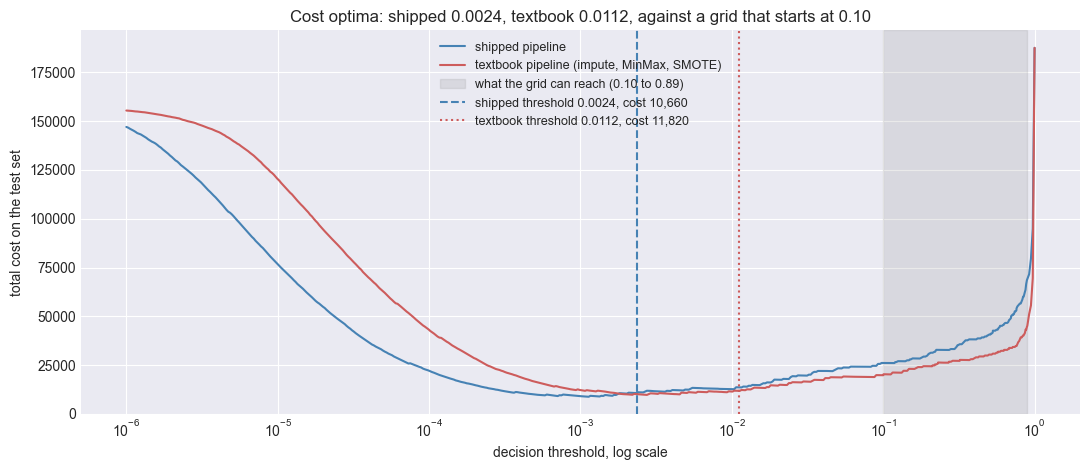

In [13]:
# Both pipelines' cost against every threshold, on the test set. The shaded band
# is what the grid could reach; the shipped optimum is outside it.
cuts = np.unique(np.concatenate([
    np.logspace(-6, 0, 500), GRID, [threshold, oof_exact_cut]]))
shipped_curve = [counts(y_test, (test_scores >= t).astype(int))['cost'] for t in cuts]
textbook_curve = [counts(y_test, (textbook_scores >= t).astype(int))['cost'] for t in cuts]

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(cuts, shipped_curve, color='steelblue', label='shipped pipeline')
ax.plot(cuts, textbook_curve, color='indianred',
        label='textbook pipeline (impute, MinMax, SMOTE)')
ax.axvspan(GRID[0], GRID[-1], color='grey', alpha=0.16,
           label=f'what the grid can reach ({GRID[0]:.2f} to {GRID[-1]:.2f})')
ax.axvline(threshold, color='steelblue', linestyle='--',
           label=f'shipped threshold {threshold:.4f}, cost {primary["cost"]:,}')
ax.axvline(oof_exact_cut, color='indianred', linestyle=':',
           label=f'textbook threshold {oof_exact_cut:.4f}, '
                 f'cost {textbook_results["exact_tuned_out_of_fold"]["cost"]:,}')
ax.set_xscale('log')
ax.set_xlabel('decision threshold, log scale')
ax.set_ylabel('total cost on the test set')
ax.set_title(f'Cost optima: shipped {threshold:.4f}, textbook {oof_exact_cut:.4f}, '
             f'against a grid that starts at {GRID[0]:.2f}')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, 'scania_model_textbook_pipeline', subfolder=ASSETS)
plt.show()

## 11. What the threshold is worth

The same model and the same probabilities read at two different cuts. Accuracy is above 99 per cent at both, which is exactly why it is the wrong instrument here.

  ✓ Saved → assets\ml\scania_model_confusion.png


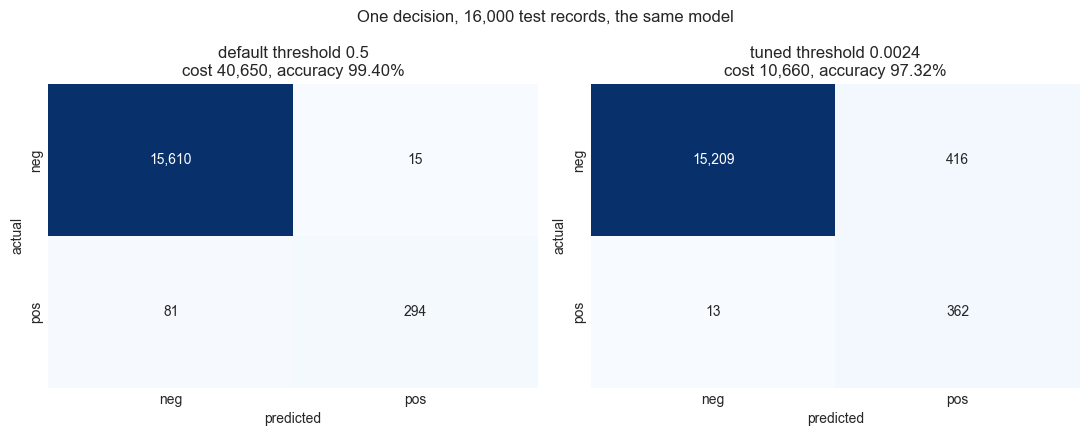

the threshold is worth 29,990 cost, a factor of 3.8
failures caught: 294 at 0.5 against 362 at 0.0024, of 375


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, cut, title in [
        (axes[0], 0.5, 'default threshold 0.5'),
        (axes[1], threshold, f'tuned threshold {threshold:.4f}')]:
    matrix = confusion_matrix(y_test, (test_scores >= cut).astype(int), labels=[0, 1])
    sns.heatmap(matrix, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    cost = counts(y_test, (test_scores >= cut).astype(int))
    accuracy = (matrix[0, 0] + matrix[1, 1]) / matrix.sum()
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    ax.set_title(f'{title}\ncost {cost["cost"]:,}, accuracy {100 * accuracy:.2f}%')

plt.suptitle('One decision, 16,000 test records, the same model')
plt.tight_layout()
save_figure(fig, 'scania_model_confusion', subfolder=ASSETS)
plt.show()

saved = ablation[chosen + '__default_threshold_0.5']['cost'] - primary['cost']
print(f'the threshold is worth {saved:,} cost, a factor of '
      f'{ablation[chosen + "__default_threshold_0.5"]["cost"] / primary["cost"]:.1f}')
print(f'failures caught: {ablation[chosen + "__default_threshold_0.5"]["true_positives"]} '
      f'at 0.5 against {primary["true_positives"]} at {threshold:.4f}, of '
      f'{int(y_test.sum())}')

## 12. Priority bands

Charter section 7.1 asks each module to document its own risk-score-to-priority
mapping next to the model. This one uses the predicted probability directly, and
the bands are confidence bands rather than distances from the threshold: the
threshold sits near zero, so a flag at 0.003 and a flag at 0.99 are the same
decision and a very different conversation.

Below the threshold nothing is published. CMAPSS emits one event per engine
because 707 engines is a fleet an operator watches; here the P4 count below is
what publishing everything would bury the incident store under.

In [15]:
bands = pd.DataFrame([
    {'priority': 'P1', 'band': 'probability >= 0.90',
     'records': int((test_scores >= 0.90).sum())},
    {'priority': 'P2', 'band': '0.50 to 0.90',
     'records': int(((test_scores >= 0.50) & (test_scores < 0.90)).sum())},
    {'priority': 'P3', 'band': f'{threshold:.4f} to 0.50',
     'records': int(((test_scores >= threshold) & (test_scores < 0.50)).sum())},
    {'priority': 'P4', 'band': 'below the threshold, no event emitted',
     'records': int((test_scores < threshold).sum())}])
bands['share_%'] = (100 * bands.records / len(y_test)).round(2)
print(bands.to_string(index=False))
print(f'\nevents emitted: {int(bands.records[:3].sum()):,} of {len(y_test):,} records')

priority                                  band  records  share_%
      P1                   probability >= 0.90      240     1.50
      P2                          0.50 to 0.90       69     0.43
      P3                        0.0024 to 0.50      469     2.93
      P4 below the threshold, no event emitted    15222    95.14

events emitted: 778 of 16,000 records


## 13. Write the artifacts

The model, the preprocessing the event adapter needs, the prediction table and
the metrics file. The column names are not free: `events/make_events_scania.py`
reads `failure_probability` and `true_class` by name.

In [16]:
joblib.dump(model, CKPT_DIR / 'scania_xgboost_v1.pkl')
joblib.dump({'imputer': imputer if impute else None, 'scaler': scaler,
             'features': features, 'median_imputation': impute,
             'threshold': threshold},
            PROC_DIR / 'preprocessing_scania.pkl')

predictions = pd.DataFrame({
    'row_id': np.arange(len(y_test)),
    'true_class': y_test,
    'failure_probability': test_scores,
    'predicted_class': (test_scores >= threshold).astype(int)})
predictions.to_csv(PROC_DIR / 'test_scania_predictions.csv', index=False)

meta = {
    'dataset': 'APS Failure at Scania Trucks, IDA 2016 Industrial Challenge',
    'train_rows': int(len(y_train)), 'test_rows': int(len(y_test)),
    'features': len(features),
    'positives_train': int(y_train.sum()), 'positives_test': int(y_test.sum()),
    'missing_cell_fraction': round(float(X_train.isna().to_numpy().mean()), 4),
    'cost_false_positive': COST_FALSE_POSITIVE,
    'cost_false_negative': COST_FALSE_NEGATIVE,
    'folds': FOLDS, 'selection_seeds': list(SELECTION_SEEDS),
    'selection_rule': ('lowest MEAN out-of-fold cost over three fold seeds; the test set is '
                       'scored once. One seed is not enough: three seeds produce three '
                       'different winners'),
    'candidate_spread': round(float(spread), 4),
    'winner_per_seed': {str(k): v for k, v in winner_per_seed.items()},
    'chosen': chosen, 'chosen_threshold': round(threshold, 6),
    'selection': selection, 'results': ablation,
    'textbook_pipeline': {
        'description': ('median imputation, MinMax scaling, SMOTE to a 50-50 split, the same '
                        'hyperparameters, threshold from the 0.10 to 0.89 grid'),
        'smote_train_rows': int(len(textbook_train)),
        'results': textbook_results},
    'priority_bands': bands.set_index('priority').records.to_dict(),
    'xgb_params': XGB_PARAMS,
    'produced_by': 'notebooks/02_ml/03_scania_modeling.ipynb',
    'published_reference': {
        'note': 'Top three of the IDA 2016 challenge, from the dataset description',
        'best_total_cost': 9920, 'second': 10900, 'third': 11480}}

META_PATH.write_text(json.dumps(meta, indent=2) + '\n', encoding='utf-8')

for path in (CKPT_DIR / 'scania_xgboost_v1.pkl', PROC_DIR / 'preprocessing_scania.pkl',
             PROC_DIR / 'test_scania_predictions.csv', META_PATH):
    print(f'  {path.name:32s} {path.stat().st_size / 1e6:8.3f} MB')

  scania_xgboost_v1.pkl               1.458 MB
  preprocessing_scania.pkl            0.008 MB
  test_scania_predictions.csv         0.381 MB
  scania_aps_meta.json                0.007 MB


## 14. Does this reproduce the recorded run

The reference was read in section 3, before anything was trained, and it is what
the model card, the charter and the README quote. Nothing above was imported from
the training script, so an agreement here is a real reproduction rather than a
tautology.

In [17]:
def show(value):
    """Integers as integers, means with one decimal, both with thousands separators."""
    return f'{value:,.1f}' if isinstance(value, float) else f'{value:,}'


if reference is None:
    print('first run, nothing to compare against')
else:
    rows = []
    for name in sorted(set(ablation) & set(reference['results'])):
        for field in ('cost', 'false_positives', 'false_negatives'):
            rows.append((f'{name} {field}', ablation[name][field],
                         reference['results'][name][field]))
    for name in sorted(set(selection) & set(reference['selection'])):
        rows.append((f'{name} mean out-of-fold cost',
                     selection[name]['mean_out_of_fold_cost'],
                     reference['selection'][name]['mean_out_of_fold_cost']))

    print(f'{"measurement":<52}{"here":>13}{"recorded":>13}{"delta":>12}')
    print('-' * 90)
    worst, moved = 0.0, 0
    for label, mine, theirs in rows:
        delta = round(mine - theirs, 3)
        worst = max(worst, abs(delta))
        moved += int(delta != 0)
        print(f'{label:<52}{show(mine):>13}{show(theirs):>13}{show(delta):>12}')
    print('-' * 90)
    print(f'{len(rows)} values compared, {moved} moved, '
          f'largest absolute difference {show(worst)}')
    print(f'chosen candidate: {chosen} here, {reference["chosen"]} recorded')
    print(f'threshold: {threshold:.6f} here, {reference["chosen_threshold"]:.6f} recorded')

measurement                                                  here     recorded       delta
------------------------------------------------------------------------------------------
imputed_plain cost                                         12,050       12,050           0
imputed_plain false_positives                                 305          305           0
imputed_plain false_negatives                                  18           18           0
imputed_weighted cost                                       9,880        9,880           0
imputed_weighted false_positives                              438          438           0
imputed_weighted false_negatives                               11           11           0
logistic_regression cost                                   15,330       15,330           0
logistic_regression false_positives                           533          533           0
logistic_regression false_negatives                            20           20           0

## 15. Log the run

The tracking store held four runs, all of them CMAPSS, while the project ships a Scania model. This puts the Scania run beside them.

In [18]:
mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment('arkon-ml-scania')

with mlflow.start_run(run_name='scania_aps_notebook'):
    mlflow.log_params({**XGB_PARAMS, 'candidate': chosen,
                       'median_imputation': impute, 'class_weighting': weighted,
                       'threshold': threshold, 'folds': FOLDS,
                       'selection_seeds': '+'.join(str(s) for s in SELECTION_SEEDS),
                       'train_rows': len(y_train), 'features': len(features)})
    mlflow.log_metrics({
        'cost': primary['cost'],
        'false_positives': primary['false_positives'],
        'false_negatives': primary['false_negatives'],
        'recall': primary['recall'], 'precision': primary['precision'],
        'roc_auc': primary['roc_auc'], 'pr_auc': primary['pr_auc'],
        'cost_at_default_threshold': ablation[chosen + '__default_threshold_0.5']['cost'],
        'cost_logistic_regression': ablation['logistic_regression']['cost'],
        'cost_textbook_pipeline': textbook_results['exact_tuned_out_of_fold']['cost'],
        'candidate_spread': spread})
    print('logged run', mlflow.active_run().info.run_id)

logged run 88418f1e9dc34465a31fa4c09c3e5110


## 16. Results

Filled in by the run above rather than by hand: the three sentences this module is worth, printed from the numbers just measured.

In [19]:
default = ablation[chosen + '__default_threshold_0.5']
configurations = {k: v for k, v in ablation.items() if 'default_threshold' not in k}
best_test = min(configurations.items(), key=lambda kv: kv[1]['cost'])
textbook_best = textbook_results['exact_tuned_out_of_fold']
published = meta['published_reference']

print(f'1. The threshold is worth {default["cost"] - primary["cost"]:,} cost, a factor '
      f'of {default["cost"] / primary["cost"]:.1f}. The same model catches '
      f'{default["true_positives"]} of {int(y_test.sum())} failures at 0.5 and '
      f'{primary["true_positives"]} at {threshold:.4f}.')
print(f'2. Every structural choice is inside the noise. The four candidates span '
      f'{min(v["cost"] for k, v in ablation.items() if k in selection):,} to '
      f'{max(v["cost"] for k, v in ablation.items() if k in selection):,} on the test '
      f'set and {100 * spread:.1f} per cent on out-of-fold cost, and '
      f'{len(set(winner_per_seed.values()))} different candidates win on '
      f'{len(SELECTION_SEEDS)} fold seeds.')
print(f'3. The textbook pipeline costs {textbook_best["cost"]:,} against '
      f'{primary["cost"]:,}, having spent an imputer, a scaler and '
      f'{len(textbook_train) - len(y_train):,} synthetic rows to get there.')
if best_test[0] == chosen:
    print('\nThe configuration that scores best on the test set is also the one that '
          'won out of fold, so the honest protocol cost nothing this time.')
else:
    print(f'\nThe honest protocol cost {primary["cost"] - best_test[1]["cost"]:,}: '
          f'{best_test[0]} scores {best_test[1]["cost"]:,} on the test set but did not '
          f'win out of fold, and picking it would mean choosing on the test set.')
print(f'\nPublished top three of the same challenge on this test set: '
      f'{published["best_total_cost"]:,} / {published["second"]:,} / '
      f'{published["third"]:,}. This model: {primary["cost"]:,}.')

1. The threshold is worth 29,990 cost, a factor of 3.8. The same model catches 294 of 375 failures at 0.5 and 362 at 0.0024.
2. Every structural choice is inside the noise. The four candidates span 9,880 to 12,050 on the test set and 4.0 per cent on out-of-fold cost, and 3 different candidates win on 3 fold seeds.
3. The textbook pipeline costs 11,820 against 10,660, having spent an imputer, a scaler and 58,000 synthetic rows to get there.

The honest protocol cost 780: imputed_weighted scores 9,880 on the test set but did not win out of fold, and picking it would mean choosing on the test set.

Published top three of the same challenge on this test set: 9,920 / 10,900 / 11,480. This model: 10,660.
